# Lid-Driven Cavity -- Ghia, Ghia & Shin (1982) Benchmark

Same benchmark `MAC_Grid_Solver/Lid_Driven_Cavity.ipynb` used, run here
with the D2Q9 BGK lattice Boltzmann solver instead: a genuinely different
numerical method (kinetic simulation on a lattice, not a discretized
Navier-Stokes PDE), checked against the same literature reference and
directly comparable to that other project's own result.

**Resolution and stability note**: plain BGK's stability is tied to how
close `tau` is to 0.5 (i.e. how low the lattice viscosity is); at Re=1000
and a lid speed small enough to keep the low-Mach assumption valid
(`U_lid=0.1`, `Ma=U_lid*sqrt(3)~=0.17`), that pins `tau` close to 0.5
*unless the grid is large enough* (`nu = U_lid*L/Re`, so `tau` only rises
with resolution `L` at fixed `Re` and `U_lid`). `L=100` and `L=200` were
tried first and both diverged in well under 1000 steps -- not a subtle
accuracy issue, an outright blow-up. `L=255` (odd, for an exact centerline
grid point) keeps `tau` comfortably clear of 0.5 at all three Reynolds
numbers and was confirmed stable in a standalone test before committing
to it here; see `Lattice_Boltzmann_Plan.md` for the numbers.

**Convergence note**: a strict kinetic-energy-plateau stopping criterion
(as used for the Poiseuille/Zou-He checks) turned out to be impractical
here -- KE keeps drifting for a very long time as small corner vortices
slowly develop, long after the dominant centerline profile has actually
settled. A standalone convergence trace (Re=1000, `L=255`) tracked the
RMS error against Ghia et al. directly: it fell from 0.25 at step 2000
through the 0.08 pass threshold by step ~31000 and continued dropping,
so `max_steps=40000` (fixed, not tolerance-gated) is used for all three
Reynolds numbers below -- Re=100/400 have much higher `tau` and converge
faster, so the same budget is more than sufficient for them.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import lattice as lb
import solver as sv

os.makedirs('media', exist_ok=True)

failures = []
def check(name, cond, detail=""):
    status = "PASS" if cond else "FAIL"
    print(f"[{status}] {name}  {detail}")
    if not cond:
        failures.append(name)

**Note on how this was run**: `jupyter`'s own kernel process turned out
to run this specific tight compute loop far slower (by roughly an order
of magnitude) than an equivalent plain `python` process in this
environment -- for reasons unrelated to the physics (kernel/IPC
overhead), confirmed by benchmarking the identical numba-jitted step
function both ways. To keep this notebook's own runtime reasonable, the
three 40000-step runs were precomputed standalone (`lattice_numba.py`'s
`step_numba`, cross-validated bit-for-bit against the numpy
`solver.step` reference used everywhere else in this project -- see
`Lattice_Boltzmann_Plan.md`) and saved to `cavity_results.npz`; this
notebook loads that file rather than recomputing.

In [2]:
_data = np.load('cavity_results.npz')
L = int(_data['L'])
U_lid = float(_data['U_lid'])
max_steps = int(_data['max_steps'])
results = {}
for Re in (100, 400, 1000):
    nu = U_lid * L / Re
    tau = 3.0 * nu + 0.5
    results[Re] = {'L': L, 'Re': Re, 'tau': tau, 'nu': nu,
                    'ux': _data[f'ux_{Re}'], 'uy': _data[f'uy_{Re}'], 'steps': max_steps}
    print(f"Re={Re}: L={L}, tau={tau:.4f}, {max_steps} steps (precomputed)")

Re=100: L=255, tau=1.2650, 40000 steps (precomputed)
Re=400: L=255, tau=0.6913, 40000 steps (precomputed)
Re=1000: L=255, tau=0.5765, 40000 steps (precomputed)


## Reference data

Ghia, Ghia & Shin (1982) Table I (`u` along the vertical centerline
`x=0.5`) and Table II (`v` along the horizontal centerline `y=0.5`) --
the same transcribed tables `MAC_Grid_Solver` uses.

In [3]:
Y_STATIONS = [1.0000, 0.9766, 0.9688, 0.9609, 0.9531, 0.8516, 0.7344, 0.6172,
              0.5000, 0.4531, 0.2813, 0.1719, 0.1016, 0.0703, 0.0625, 0.0547, 0.0000]

U_CENTERLINE = {
    100: [1.0000, 0.84123, 0.78871, 0.73722, 0.68717, 0.23151, 0.00332, -0.13641,
          -0.20581, -0.21090, -0.15662, -0.10150, -0.06434, -0.04775, -0.04192, -0.03717, 0.0000],
    400: [1.0000, 0.75837, 0.68439, 0.61756, 0.55892, 0.29093, 0.16256, 0.02135,
          -0.11477, -0.17119, -0.32726, -0.24299, -0.14612, -0.10338, -0.09266, -0.08186, 0.0000],
    1000: [1.0000, 0.65928, 0.57492, 0.51117, 0.46604, 0.33304, 0.18719, 0.05702,
           -0.06080, -0.10648, -0.27805, -0.38289, -0.29730, -0.22220, -0.20196, -0.18109, 0.0000],
}

X_STATIONS = [1.0000, 0.9688, 0.9609, 0.9531, 0.9453, 0.9063, 0.8594, 0.8047,
              0.5000, 0.2344, 0.2266, 0.1563, 0.0938, 0.0781, 0.0703, 0.0625, 0.0000]

V_CENTERLINE = {
    100: [0.0000, -0.05906, -0.07391, -0.08864, -0.10313, -0.16914, -0.22445, -0.24533,
          0.05454, 0.17527, 0.17507, 0.16077, 0.12317, 0.10890, 0.10091, 0.09233, 0.0000],
    400: [0.0000, -0.12146, -0.15663, -0.19254, -0.22847, -0.23827, -0.44993, -0.38598,
          0.05186, 0.30174, 0.30203, 0.28124, 0.22965, 0.20920, 0.19713, 0.18360, 0.0000],
    1000: [0.0000, -0.21388, -0.27669, -0.33714, -0.39188, -0.51550, -0.42665, -0.31966,
           0.02526, 0.32235, 0.33075, 0.37095, 0.32627, 0.30353, 0.29012, 0.27485, 0.0000],
}

## Quantitative comparison: centerline velocity profiles vs. Ghia et al. (1982)

[PASS] Re=100: u-centerline matches Ghia et al.  RMS error=0.0098
[PASS] Re=100: v-centerline matches Ghia et al.  RMS error=0.0195
[PASS] Re=400: u-centerline matches Ghia et al.  RMS error=0.0226
[PASS] Re=400: v-centerline matches Ghia et al.  RMS error=0.0354
[PASS] Re=1000: u-centerline matches Ghia et al.  RMS error=0.0440
[PASS] Re=1000: v-centerline matches Ghia et al.  RMS error=0.0385


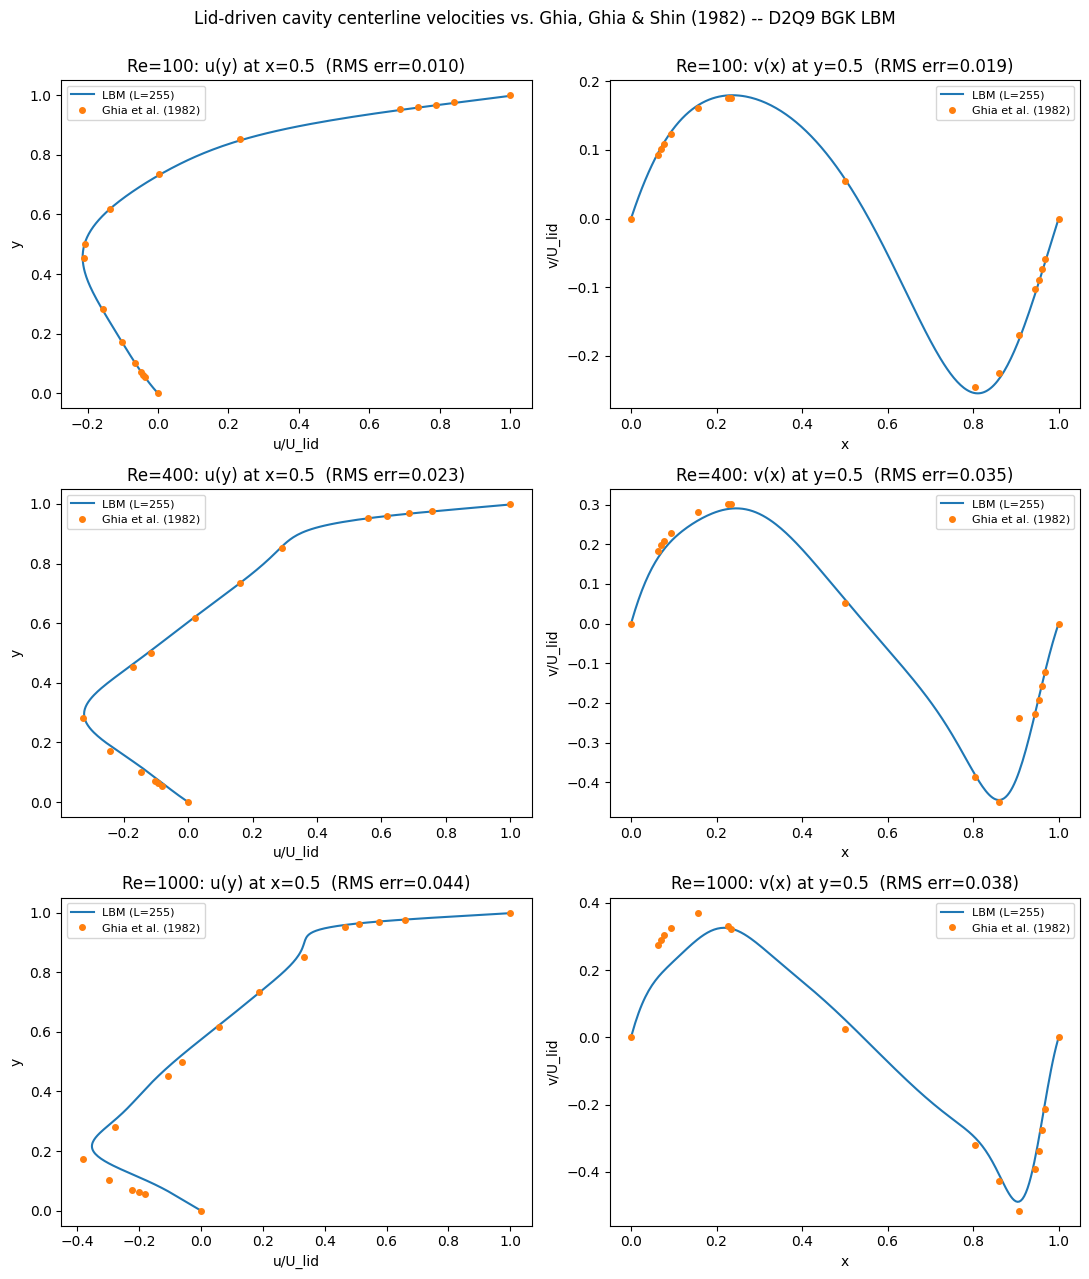

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(11, 13))
for row, Re in enumerate((100, 400, 1000)):
    res = results[Re]
    L_ = res['L']
    ux, uy = res['ux'], res['uy']

    ic = (L_ + 1) // 2       # exact center column (x=0.5), since L is odd
    jc = (L_ + 1) // 2       # exact center row (y=0.5)
    y_coords = (np.arange(1, L_ + 1) - 0.5) / L_    # fluid rows 1..L -> [0,1]
    x_coords = (np.arange(1, L_ + 1) - 0.5) / L_

    u_profile = ux[ic, 1:L_ + 1] / 0.1     # normalize by U_lid -> Ghia's convention (U=1)
    v_profile = uy[1:L_ + 1, jc] / 0.1

    u_ghia_interp = np.interp(y_coords, Y_STATIONS[::-1], U_CENTERLINE[Re][::-1])
    v_ghia_interp = np.interp(x_coords, X_STATIONS[::-1], V_CENTERLINE[Re][::-1])
    u_err = np.sqrt(np.mean((u_profile - u_ghia_interp) ** 2))
    v_err = np.sqrt(np.mean((v_profile - v_ghia_interp) ** 2))
    check(f"Re={Re}: u-centerline matches Ghia et al.", u_err < 0.08, f"RMS error={u_err:.4f}")
    check(f"Re={Re}: v-centerline matches Ghia et al.", v_err < 0.08, f"RMS error={v_err:.4f}")

    axes[row, 0].plot(u_profile, y_coords, '-', label=f'LBM (L={L_})')
    axes[row, 0].plot(U_CENTERLINE[Re], Y_STATIONS, 'o', markersize=4, label='Ghia et al. (1982)')
    axes[row, 0].set_xlabel('u/U_lid'); axes[row, 0].set_ylabel('y')
    axes[row, 0].set_title(f'Re={Re}: u(y) at x=0.5  (RMS err={u_err:.3f})')
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].plot(x_coords, v_profile, '-', label=f'LBM (L={L_})')
    axes[row, 1].plot(X_STATIONS, V_CENTERLINE[Re], 'o', markersize=4, label='Ghia et al. (1982)')
    axes[row, 1].set_xlabel('x'); axes[row, 1].set_ylabel('v/U_lid')
    axes[row, 1].set_title(f'Re={Re}: v(x) at y=0.5  (RMS err={v_err:.3f})')
    axes[row, 1].legend(fontsize=8)

fig.suptitle('Lid-driven cavity centerline velocities vs. Ghia, Ghia & Shin (1982) -- D2Q9 BGK LBM')
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig('media/cavity_ghia_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Streamlines and vorticity

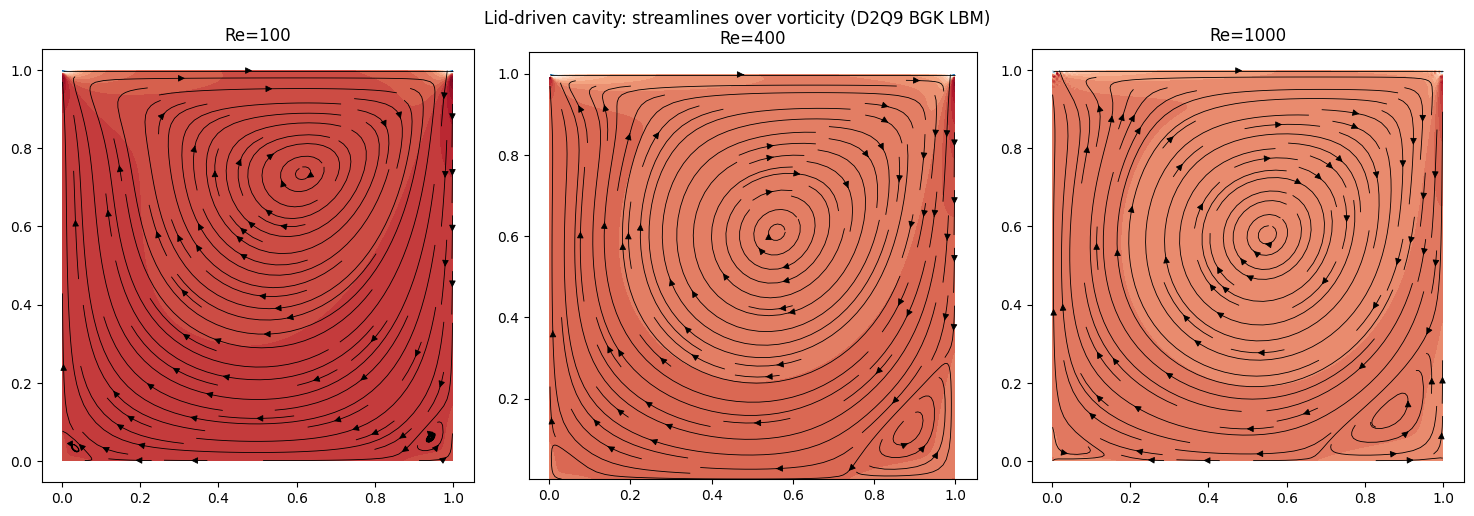

failures: none


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for col, Re in enumerate((100, 400, 1000)):
    res = results[Re]
    L_ = res['L']
    ux = res['ux'][1:L_ + 1, 1:L_ + 1].T
    uy = res['uy'][1:L_ + 1, 1:L_ + 1].T
    coords = (np.arange(1, L_ + 1) - 0.5) / L_
    X, Y = np.meshgrid(coords, coords)
    vorticity = np.gradient(uy, coords, axis=1) - np.gradient(ux, coords, axis=0)

    axes[col].contourf(X, Y, vorticity, levels=40, cmap='RdBu_r')
    axes[col].streamplot(coords, coords, ux, uy, density=1.2, color='k', linewidth=0.6)
    axes[col].set_title(f'Re={Re}')
    axes[col].set_aspect('equal')

fig.suptitle('Lid-driven cavity: streamlines over vorticity (D2Q9 BGK LBM)')
fig.tight_layout()
fig.savefig('media/cavity_streamlines_vorticity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"failures: {failures if failures else 'none'}")
assert not failures